In [114]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
import jieba

In [115]:
movies = {
    '12 Angry Men': [['Sidney Lumet'], ['Henry Fonda', 'Lee J. Cobb', 'Ed Begley']],
    '2001: A Space Odyssey': [['Stanley Kubrick'], ['Keir Dullea', 'Gary Lockwood', 'William Sylvester']],
    'A Beautiful Mind': [['Ron Howard'], ['Russell Crowe', 'Jennifer Connelly', 'Ed Harris']],
    'Avatar': [['James Cameron'], ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']],
    'Black Swan': [['Darren Aronofsky'], ['Natalie Portman', 'Mila Kunis', 'Vincent Cassel']],
    'Bohemian Rhapsody': [['Bryan Singer'], ['Rami Malek', 'Lucy Boynton', 'Gwilym Lee']],
    'Catch Me If You Can': [['Steven Spielberg'], ['Leonardo DiCaprio', 'Tom Hanks', 'Christopher Walken']],
    'Coco': [['Lee Unkrich', 'Adrian Molina'], ['Anthony Gonzalez', 'Gael García Bernal', 'Benjamin Bratt']],
    'Django Unchained': [['Quentin Tarantino'], ['Jamie Foxx', 'Christoph Waltz', 'Leonardo DiCaprio']],
    'Fight Club': [['David Fincher'], ['Brad Pitt', 'Edward Norton', 'Helena Bonham Carter']],
    'Forrest Gump': [['Robert Zemeckis'], ['Tom Hanks', 'Robin Wright', 'Gary Sinise']],
    'Frozen': [['Chris Buck', 'Jennifer Lee'], ['Kristen Bell', 'Idina Menzel', 'Jonathan Groff']],
    'Gone Girl': [['David Fincher'], ['Ben Affleck', 'Rosamund Pike', 'Neil Patrick Harris']],
    'Good Will Hunting': [['Gus Van Sant'], ['Matt Damon', 'Robin Williams', 'Ben Affleck']],
    'Green Book': [['Peter Farrelly'], ['Viggo Mortensen', 'Mahershala Ali', 'Linda Cardellini']],
    'Hacksaw Ridge': [['Mel Gibson'], ['Andrew Garfield', 'Sam Worthington', 'Luke Bracey']],
    "Harry Potter and the Sorcerer's Stone": [['Chris Columbus'], ['Daniel Radcliffe', 'Rupert Grint', 'Emma Watson']],
    'How to Train Your Dragon': [['Dean DeBlois', 'Chris Sanders'], ['Jay Baruchel', 'Gerard Butler', 'Craig Ferguson']],
    'Inception': [['Christopher Nolan'], ['Leonardo DiCaprio', 'Marion Cotillard', 'Tom Hardy']],
    'Inglourious Basterds': [['Quentin Tarantino'], ['Brad Pitt', 'Christoph Waltz', 'Mélanie Laurent']],
    'Inside Out': [['Pete Docter', 'Ronnie Del Carmen'], ['Amy Poehler', 'Phyllis Smith', 'Richard Kind']],
    'Interstellar': [['Christopher Nolan'], ['Matthew McConaughey', 'Anne Hathaway', 'Jessica Chastain']],
    'Joker': [['Todd Phillips'], ['Joaquin Phoenix', 'Robert De Niro', 'Zazie Beetz']],
    'La La Land': [['Damien Chazelle'], ['Ryan Gosling', 'Emma Stone', 'John Legend']],
    'Life Is Beautiful': [['Roberto Benigni'], ['Roberto Benigni', 'Nicoletta Braschi', 'Giorgio Cantarini']],
    'Life of Pi': [['Ang Lee'], ['Suraj Sharma', 'Irrfan Khan', 'Rafe Spall']],
    'Lock, Stock and Two Smoking Barrels': [['Guy Ritchie'], ['Jason Flemyng', 'Dexter Fletcher', 'Nick Moran']],
    'Léon: The Professional': [['Luc Besson'], ['Jean Reno', 'Natalie Portman', 'Gary Oldman']],
    'Mad Max: Fury Road': [['George Miller'], ['Tom Hardy', 'Charlize Theron', 'Nicholas Hoult']],
    'Memento': [['Christopher Nolan'], ['Guy Pearce', 'Carrie-Anne Moss', 'Joe Pantoliano']],
    'Monsters, Inc.': [['Pete Docter', 'David Silverman', 'Lee Unkrich'], ['John Goodman', 'Billy Crystal', 'Mary Gibbs']],
    "One Flew Over the Cuckoo's Nest": [['Miloš Forman'], ['Jack Nicholson', 'Louise Fletcher', 'Danny DeVito']],
    'Parasite': [['Bong Joon-ho'], ['Song Kang-ho', 'Lee Sun-kyun', 'Cho Yeo-jeong']],
    'Pirates of the Caribbean: The Curse of the Black Pearl': [['Gore Verbinski'], ['Johnny Depp', 'Geoffrey Rush', 'Orlando Bloom']],
    'Psycho': [['Alfred Hitchcock'], ['Anthony Perkins', 'Janet Leigh', 'Vera Miles']],
    'Pulp Fiction': [['Quentin Tarantino'], ['John Travolta', 'Samuel L. Jackson', 'Uma Thurman']],
    'Saving Private Ryan': [['Steven Spielberg'], ['Tom Hanks', 'Matt Damon', 'Tom Sizemore']],
    "Schindler's List": [['Steven Spielberg'], ['Liam Neeson', 'Ben Kingsley', 'Ralph Fiennes']],
    'Se7en': [['David Fincher'], ['Morgan Freeman', 'Brad Pitt', 'Gwyneth Paltrow']],
    'Shutter Island': [['Martin Scorsese'], ['Leonardo DiCaprio', 'Mark Ruffalo', 'Ben Kingsley']],
    'Slumdog Millionaire': [['Danny Boyle', 'Loveleen Tandan'], ['Dev Patel', 'Freida Pinto', 'Madhur Mittal']],
    'Spider-Man: Into the Spider-Verse': [['Bob Persichetti', 'Peter Ramsey', 'Rodney Rothman'], ['Shameik Moore', 'Jake Johnson', 'Hailee Steinfeld']],
    'Spirited Away': [['Hayao Miyazaki'], ['Rumi Hiiragi', 'Miyu Irino', 'Mari Natsuki']],
    'Terminator 2: Judgment Day': [['James Cameron'], ['Arnold Schwarzenegger', 'Linda Hamilton', 'Edward Furlong']],
    'The Bourne Ultimatum': [['Paul Greengrass'], ['Matt Damon', 'Julia Stiles', 'David Strathairn']],
    'The Curious Case of Benjamin Button': [['David Fincher'], ['Brad Pitt', 'Cate Blanchett', 'Taraji P. Henson']],
    'The Dark Knight': [['Christopher Nolan'], ['Christian Bale', 'Heath Ledger', 'Aaron Eckhart']],
    'The Godfather': [['Francis Ford Coppola'], ['Marlon Brando', 'Al Pacino', 'James Caan']],
    'The Grand Budapest Hotel': [['Wes Anderson'], ['Ralph Fiennes', 'F. Murray Abraham', 'Mathieu Amalric']],
    'The Green Mile': [['Frank Darabont'], ['Tom Hanks', 'Michael Clarke Duncan', 'David Morse']],
    'The Imitation Game': [['Morten Tyldum'], ['Benedict Cumberbatch', 'Keira Knightley', 'Matthew Goode']],
    'The Intouchables': [['Olivier Nakache', 'Éric Toledano'], ['François Cluzet', 'Omar Sy', 'Anne Le Ny']],
    'The Lion King': [['Roger Allers', 'Rob Minkoff'], ['Matthew Broderick', 'Jeremy Irons', 'James Earl Jones']],
    'The Lord of the Rings: The Return of the King': [['Peter Jackson'], ['Elijah Wood', 'Ian McKellen', 'Viggo Mortensen']],
    'The Martian': [['Ridley Scott'], ['Matt Damon', 'Jessica Chastain', 'Kristen Wiig']],
    'The Matrix': [['Lana Wachowski', 'Lilly Wachowski'], ['Keanu Reeves', 'Laurence Fishburne', 'Carrie-Anne Moss']],
    'The Notebook': [['Nick Cassavetes'], ['Ryan Gosling', 'Rachel McAdams', 'James Garner']],
    'The Pianist': [['Roman Polanski'], ['Adrien Brody', 'Thomas Kretschmann', 'Frank Finlay']],
    'The Prestige': [['Christopher Nolan'], ['Hugh Jackman', 'Christian Bale', 'Michael Caine']],
    'The Shawshank Redemption': [['Frank Darabont'], ['Tim Robbins', 'Morgan Freeman', 'Bob Gunton']],
    'The Silence of the Lambs': [['Jonathan Demme'], ['Jodie Foster', 'Anthony Hopkins', 'Scott Glenn']],
    'The Sixth Sense': [['M. Night Shyamalan'], ['Bruce Willis', 'Haley Joel Osment', 'Toni Collette']],
    'The Truman Show': [['Peter Weir'], ['Jim Carrey', 'Laura Linney', 'Noah Emmerich']],
    'Titanic': [['James Cameron'], ['Leonardo DiCaprio', 'Kate Winslet', 'Billy Zane']],
    'Toy Story 3': [['Lee Unkrich'], ['Tom Hanks', 'Tim Allen', 'Joan Cusack']],
    'Up': [['Pete Docter', 'Bob Peterson'], ['Ed Asner', 'Christopher Plummer', 'Jordan Nagai']],
    'WALL·E': [['Andrew Stanton'], ['Ben Burtt', 'Elissa Knight', 'Jeff Garlin']],
    'Whiplash': [['Damien Chazelle'], ['Miles Teller', 'J.K. Simmons', 'Paul Reiser']]
}

In [116]:
# Load CSVs
df_en = pd.read_csv('../imdb_reviews.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [117]:
#function of all of this is to get rid self mentions of titles, actors, and director
import re
import nltk
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz
import string

nltk.download('stopwords', quiet=True)

SPECIAL_TOKENS = {"<MOVIE_TITLE>", "<DIRECTOR_NAME>", "<ACTOR_NAME>"}

def normalize_for_matching(text):
    """Normalize text for matching purposes only."""
    return re.sub(r"[^\w\s]", "", text.lower())

def find_title_mentions(text, title):
    """
    Find all exact, case-insensitive, whole-word matches of the movie title.
    Returns a list of (start, end, tag) tuples.
    """
    matches = []
    if not title or len(title) < 2:
        return matches
    
    # Create pattern that handles word boundaries properly
    pattern = r'\b' + re.escape(title) + r'\b'
    
    for m in re.finditer(pattern, text, flags=re.IGNORECASE):
        matches.append((m.start(), m.end(), "<MOVIE_TITLE>"))
    
    return matches

def find_name_mentions(text, names, min_ratio=85):
    """
    Find matches for director/actor names in text with improved accuracy.
    """
    matches = []
    
    for name, tag in names:
        if not name or len(name.split()) < 2:
            continue
            
        # Try exact match first (case-insensitive)
        pattern = r'\b' + re.escape(name) + r'\b'
        for m in re.finditer(pattern, text, flags=re.IGNORECASE):
            matches.append((m.start(), m.end(), tag))
        
        # Try possessive form (e.g., "Nolan's" for "Christopher Nolan")
        last_name = name.split()[-1]
        if len(last_name) > 2:  # Avoid matching very short names
            possessive_pattern = r'\b' + re.escape(last_name) + r"'s?\b"
            for m in re.finditer(possessive_pattern, text, flags=re.IGNORECASE):
                # Verify this isn't part of a common word
                match_text = text[m.start():m.end()].lower()
                if not is_common_word_with_s(match_text.rstrip("'s")):
                    matches.append((m.start(), m.end(), tag))
        
        # Try partial name matching with stricter criteria
        name_parts = name.lower().split()
        if len(name_parts) >= 2:
            # Look for first + last name
            first_last_pattern = r'\b' + re.escape(name_parts[0]) + r'\s+' + re.escape(name_parts[-1]) + r'\b'
            for m in re.finditer(first_last_pattern, text, flags=re.IGNORECASE):
                matches.append((m.start(), m.end(), tag))
            
            # Look for just last name if it's distinctive enough
            if len(name_parts[-1]) >= 4 and name_parts[-1] not in get_common_words():
                last_name_pattern = r'\b' + re.escape(name_parts[-1]) + r'\b'
                for m in re.finditer(last_name_pattern, text, flags=re.IGNORECASE):
                    # Check context to avoid false positives
                    if is_likely_name_reference(text, m.start(), m.end()):
                        matches.append((m.start(), m.end(), tag))
    
    return matches

def is_common_word_with_s(word):
    """Check if a word is a common English word that might end with 's."""
    common_words = {
        'his', 'hers', 'its', 'theirs', 'ours', 'yours', 'this', 'that',
        'was', 'has', 'does', 'goes', 'comes', 'makes', 'takes', 'gives',
        'seems', 'looks', 'feels', 'sounds', 'appears', 'becomes'
    }
    return word.lower() in common_words

def get_common_words():
    """Get a set of common English words to avoid matching."""
    return {
        'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'it',
        'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at', 'this',
        'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her', 'she', 'or',
        'an', 'will', 'my', 'one', 'all', 'would', 'there', 'their', 'what',
        'so', 'up', 'out', 'if', 'about', 'who', 'get', 'which', 'go', 'me',
        'when', 'make', 'can', 'like', 'time', 'no', 'just', 'him', 'know',
        'take', 'people', 'into', 'year', 'your', 'good', 'some', 'could',
        'them', 'see', 'other', 'than', 'then', 'now', 'look', 'only', 'come',
        'its', 'over', 'think', 'also', 'back', 'after', 'use', 'two', 'how',
        'our', 'work', 'first', 'well', 'way', 'even', 'new', 'want', 'because',
        'any', 'these', 'give', 'day', 'most', 'us', 'still', 'find', 'tell',
        'really', 'dark', 'great', 'movie', 'film', 'scene', 'character', 'story',
        'plot', 'director', 'actor', 'actress', 'hero', 'villain', 'killer',
        'murder', 'death', 'child', 'mind', 'moral', 'figure', 'foundation'
    }

def is_likely_name_reference(text, start, end):
    """Check if a match is likely to be a name reference based on context."""
    # Look at surrounding context
    context_start = max(0, start - 20)
    context_end = min(len(text), end + 20)
    context = text[context_start:context_end].lower()
    
    # Positive indicators
    name_indicators = ['directed by', 'starring', 'actor', 'actress', 'star', 
                      'performance', 'played by', 'cast', 'role']
    
    # Negative indicators (words that suggest it's not a name)
    not_name_indicators = ['the', 'a', 'an', 'is', 'was', 'were', 'are',
                           'his', 'her', 'its', 'their', 'this', 'that']
    
    # Check for positive indicators
    for indicator in name_indicators:
        if indicator in context:
            return True
    
    # Check if the word immediately before is a negative indicator
    word_before = text[max(0, start-10):start].strip().split()[-1:] if start > 0 else []
    if word_before and word_before[0].lower() in not_name_indicators:
        return False
    
    return True

def remove_overlapping(matches):
    """Remove overlapping matches, keeping the longest ones."""
    if not matches:
        return []
    
    # Sort by start position, then by length (longest first)
    matches = sorted(matches, key=lambda x: (x[0], -(x[1]-x[0])))
    
    result = []
    last_end = -1
    
    for start, end, tag in matches:
        if start >= last_end:
            result.append((start, end, tag))
            last_end = end
    
    return result

def preprocess_movie_review(text, movies, title):
    """
    Preprocess a movie review with improved entity recognition.
    """
    if title not in movies:
        # Just do basic preprocessing if movie not in dictionary
        text_lower = text.lower()
        text_no_punct = re.sub(r"[^\w\s]", "", text_lower)
        words = text_no_punct.split()
        stops = set(stopwords.words("english"))
        cleaned = [w for w in words if w not in stops]
        return " ".join(cleaned)
    
    directors, actors = movies[title]
    
    # Find all entity matches
    entity_matches = []
    
    # Find title mentions
    entity_matches.extend(find_title_mentions(text, title))
    
    # Find director and actor mentions
    entity_matches.extend(find_name_mentions(text, [(d, "<DIRECTOR_NAME>") for d in directors]))
    entity_matches.extend(find_name_mentions(text, [(a, "<ACTOR_NAME>") for a in actors]))
    
    # Remove overlapping matches
    entity_matches = remove_overlapping(entity_matches)
    
    # Replace entities in text (from end to start to preserve indices)
    new_text = text
    for start, end, tag in sorted(entity_matches, key=lambda x: -x[0]):
        new_text = new_text[:start] + tag + new_text[end:]
    
    # Lowercase and remove punctuation
    new_text = new_text.lower()
    
    # Preserve special tokens while removing punctuation
    for token in SPECIAL_TOKENS:
        new_text = new_text.replace(token.lower(), f" {token} ")
    
    # Remove punctuation except for angle brackets
    new_text = re.sub(r"[^\w\s<>]", " ", new_text)
    
    # Tokenize
    words = new_text.split()
    
    # Remove stopwords except special tokens
    stops = set(stopwords.words("english"))
    cleaned = [w for w in words if w in SPECIAL_TOKENS or w not in stops]
    
    return " ".join(cleaned)

In [118]:
df_en['processed_comment'] = df_en.apply(
    lambda row: preprocess_movie_review(row['comment'], movies, row['title']),
    axis=1
)

In [119]:
#load in custom stopwords
custom_stopwords = set(open('../text_processing/custom_english_stopwords.txt', encoding='utf-8').read().split())
words = []
for word in custom_stopwords:
    word = word.lower()
    words.append(word)
custom_stopwords = set(words)

In [120]:
# English preprocessing
def clean_english(text):
    text = str(text).lower()
    words = [w for w in text.split() if w not in custom_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_en['clean_comment'] = df_en['processed_comment'].apply(clean_english)

In [121]:
comments = df_en["clean_comment"].dropna().tolist()

In [122]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(comments, show_progress_bar=True)

Batches: 100%|██████████| 241/241 [01:34<00:00,  2.54it/s]


In [123]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 10 # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_en['cluster'] = labels

In [124]:
df_en['cluster'].value_counts()

cluster
9    1253
8    1063
6     963
4     943
0     754
1     702
3     608
5     545
7     507
2     369
Name: count, dtype: int64

In [125]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from keybert import KeyBERT
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def extract_keybert_keywords(df_en, model, num_keywords=10):
    print("=== KEYBERT KEYWORDS ===\n")
    kw_model = KeyBERT(model)
    for i in range(num_clusters):
        cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
        joined = " ".join(cluster_comments)
        keywords = kw_model.extract_keywords(joined, top_n=num_keywords)
        print(f"Cluster {i} keywords:", keywords)

def analyze_clusters_comprehensive(df_en, text_column='processed_comment'):
    """
    Comprehensive cluster analysis with multiple methods
    """
    
    # 1. TF-IDF Based Analysis (most discriminative terms per cluster)
    print("=== TF-IDF DISCRIMINATIVE TERMS ===\n")
    
    # Create a document for each cluster by joining all comments
    cluster_docs = []
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist())
        cluster_docs.append(cluster_text)
    
    # Compute TF-IDF
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 3), stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()
    
    # Get top terms for each cluster based on TF-IDF scores
    for i in range(len(cluster_docs)):
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[-15:][::-1]  # Top 15 terms
        top_terms = [(feature_names[idx], scores[idx]) for idx in top_indices]
        
        print(f"Cluster {i} - Most Discriminative Terms:")
        for term, score in top_terms[:10]:
            print(f"  {term}: {score:.3f}")
        print()
    
    # 3. Movie and Rating Distribution
    print("\n=== MOVIE & RATING DISTRIBUTION ===\n")
    
    for i in range(df_en['cluster'].nunique()):
        cluster_df = df_en[df_en['cluster'] == i]
        
        print(f"Cluster {i}:")
        print(f"  Size: {len(cluster_df)} reviews")
        
        # Top movies in this cluster
        top_movies = cluster_df['title'].value_counts().head(5)
        print(f"  Top movies:")
        for movie, count in top_movies.items():
            print(f"    - {movie}: {count} reviews")
        
        # Rating distribution if available
        if 'rating' in df_en.columns:
            print(f"  Average rating: {cluster_df['rating'].mean():.2f}")
            print(f"  Rating std: {cluster_df['rating'].std():.2f}")
        
        print()

    # 5. Length Analysis
    print("\n=== REVIEW LENGTH ANALYSIS ===\n")
    
    df_en['review_length'] = df_en[text_column].str.split().str.len()
    
    for i in range(df_en['cluster'].nunique()):
        cluster_lengths = df_en[df_en['cluster'] == i]['review_length']
        print(f"Cluster {i}:")
        print(f"  Average length: {cluster_lengths.mean():.1f} words")
        print(f"  Median length: {cluster_lengths.median():.1f} words")
        print()
    
    # 4. Special Token Analysis
    print("\n=== SPECIAL TOKEN USAGE ===\n")
    
    special_tokens = [ 'director_name', 'actor_name']
    
    for i in range(df_en['cluster'].nunique()):
        cluster_comments = df_en[df_en['cluster'] == i][text_column].tolist()
        all_text = ' '.join(cluster_comments)
        
        print(f"Cluster {i}:")
        for token in special_tokens:
            count = all_text.count(token)
            avg_per_review = count / len(cluster_comments)
            print(f"  {token}: {count} total ({avg_per_review:.2f} per review)")
        print()

def get_sample_reviews(df_en, n_samples=3):
#print some random comments from each cluster
    """
    Get representative reviews from each cluster
    """
    print("\n=== RANDOM SAMPLE REVIEWS ===\n")
    
    for cluster_num in sorted(df_en['cluster'].unique()):
        print(f"\nCluster {cluster_num}:")
        sample_comments = df_en[df_en['cluster'] == cluster_num]['comment'].sample(n_samples, random_state=42)
        for comment in sample_comments:
            print(" -", comment)
            print()
        print("-" * 40)

def extract_unique_ngrams(df_en, text_column='processed_comment'):
    """
    Find n-grams that are unique or highly specific to each cluster
    """
    print("\n=== UNIQUE N-GRAMS PER CLUSTER ===\n")
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    # Get n-grams for each cluster
    cluster_ngrams = {}
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = df_en[df_en['cluster'] == i][text_column].tolist()
        
        # Extract bigrams and trigrams
        vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=100)
        try:
            ngram_counts = vectorizer.fit_transform(cluster_text)
            feature_names = vectorizer.get_feature_names_out()
            
            # Sum occurrences across all documents in cluster
            total_counts = ngram_counts.sum(axis=0).A1
            ngram_freq = list(zip(feature_names, total_counts))
            ngram_freq.sort(key=lambda x: x[1], reverse=True)
            
            cluster_ngrams[i] = dict(ngram_freq[:20])  # Top 20 n-grams
        except:
            cluster_ngrams[i] = {}
    
    # Find n-grams unique to each cluster
    for i in range(df_en['cluster'].nunique()):
        print(f"Cluster {i} - Unique/Distinctive N-grams:")
        
        current_ngrams = set(cluster_ngrams[i].keys())
        other_ngrams = set()
        
        for j in range(df_en['cluster'].nunique()):
            if j != i:
                other_ngrams.update(cluster_ngrams[j].keys())
        
        unique_ngrams = current_ngrams - other_ngrams
        
        if unique_ngrams:
            for ngram in list(unique_ngrams)[:10]:
                print(f"  - {ngram}: {cluster_ngrams[i][ngram]} occurrences")
        else:
            # If no unique n-grams, show most frequent
            for ngram, count in list(cluster_ngrams[i].items())[:5]:
                print(f"  - {ngram}: {count} occurrences")
        print()

def visualize_clusters(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction
    """
    # PCA visualization
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                         c=df_en['cluster'], cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Clusters in PCA Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    # t-SNE visualization (for smaller datasets)
    if len(df_en) < 5000:  # t-SNE is computationally expensive
        tsne = TSNE(n_components=2, random_state=42)
        tsne_coords = tsne.fit_transform(embeddings)
        
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], 
                             c=df_en['cluster'], cmap='tab10', alpha=0.6)
        plt.colorbar(scatter)
        plt.title('Clusters in t-SNE Space')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    
    plt.tight_layout()
    plt.show()

def visualize_clusters2(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction but different output
    """
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    df_en['x'] = reduced[:, 0]
    df_en['y'] = reduced[:, 1]

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_en, x='x', y='y', hue='cluster', palette='tab10')
    plt.title("IMDB Comment Clusters")
    plt.show()

def analyze_cluster_themes(df_en, text_column='processed_comment'):
    """
    High-level theme analysis based on semantic patterns
    """
    print("\n=== POTENTIAL CLUSTER THEMES ===\n")
    
    # Define theme indicators
    theme_patterns = {
        'Technical/Cinematography': ['cinematography', 'camera', 'shot', 'visual', 'effects', 'lighting', 'score', 'soundtrack'],
        'Plot/Story': ['plot', 'story', 'narrative', 'ending', 'twist', 'predictable', 'boring', 'confusing'],
        'Acting/Performance': ['<ACTOR_NAME>', 'actor_name', 'acting', 'performance', 'character', 'role', 'cast'],
        'Direction': ['<DIRECTOR_NAME>', 'director_name', 'direction', 'directed', 'filmmaker'],
        'Genre-specific': ['horror', 'comedy', 'thriller', 'drama', 'action', 'romantic'],
        'Emotional Response': ['love', 'hate', 'disappoint', 'amazing', 'terrible', 'worst', 'best', 'masterpiece'],
        'Critical/Analytical': ['overrated', 'underrated', 'critic', 'review', 'analysis', 'interpret'],
    }
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist()).lower()
        
        print(f"\nCluster {i} - Theme Scores:")
        theme_scores = {}
        
        for theme, keywords in theme_patterns.items():
            score = sum(cluster_text.count(keyword.lower()) for keyword in keywords)
            theme_scores[theme] = score
        
        # Normalize by cluster size
        cluster_size = len(df_en[df_en['cluster'] == i])
        
        # Sort themes by score
        sorted_themes = sorted(theme_scores.items(), key=lambda x: x[1], reverse=True)
        
        for theme, score in sorted_themes[:5]:
            normalized_score = score / cluster_size
            print(f"  {theme}: {normalized_score:.2f} mentions per review")


In [126]:
extract_keybert_keywords(df_en, model, num_keywords=10)

=== KEYBERT KEYWORDS ===

Cluster 0 keywords: [('scenes', 0.4342), ('scripts', 0.4056), ('screenwriters', 0.4032), ('critics', 0.3971), ('tarantino', 0.3918), ('blackkklansman', 0.3906), ('script', 0.3872), ('biopics', 0.3846), ('departed', 0.3833), ('directed', 0.3785)]
Cluster 1 keywords: [('tropes', 0.4462), ('portrayals', 0.4205), ('literary', 0.4158), ('rehashes', 0.4142), ('literature', 0.4127), ('anachronisms', 0.4071), ('intros', 0.4024), ('thematic', 0.3937), ('comedies', 0.3894), ('writers', 0.3872)]
Cluster 2 keywords: [('spielberg', 0.4742), ('cinematogophry', 0.4676), ('hollywoodization', 0.458), ('filmography', 0.453), ('comedies', 0.4401), ('memoirs', 0.4378), ('moviemakers', 0.4345), ('filmmakers', 0.4249), ('warfilm', 0.4231), ('biopic', 0.4211)]
Cluster 3 keywords: [('mediocrity', 0.4183), ('opinion', 0.3688), ('worstest', 0.3546), ('opinions', 0.3531), ('worst', 0.3492), ('comedy', 0.3411), ('cliches', 0.3345), ('clichés', 0.3345), ('ratings', 0.3326), ('mediocre', 0

=== TF-IDF DISCRIMINATIVE TERMS ===

Cluster 0 - Most Discriminative Terms:
  actor_name: 0.714
  best: 0.199
  people: 0.195
  great: 0.182
  acting: 0.152
  better: 0.142
  bad: 0.125
  music: 0.123
  say: 0.123
  character: 0.121

Cluster 1 - Most Discriminative Terms:
  people: 0.478
  world: 0.199
  end: 0.163
  character: 0.155
  real: 0.155
  plot: 0.153
  say: 0.149
  love: 0.147
  thing: 0.141
  man: 0.140

Cluster 2 - Most Discriminative Terms:
  war: 0.533
  director_name: 0.377
  people: 0.276
  actor_name: 0.245
  scene: 0.166
  great: 0.150
  bad: 0.134
  real: 0.117
  scenes: 0.115
  characters: 0.114

Cluster 3 - Most Discriminative Terms:
  people: 0.547
  got: 0.230
  say: 0.227
  worst: 0.212
  bad: 0.209
  thing: 0.173
  better: 0.162
  waste: 0.158
  understand: 0.144
  going: 0.137

Cluster 4 - Most Discriminative Terms:
  actor_name: 0.373
  people: 0.248
  plot: 0.240
  character: 0.230
  end: 0.227
  characters: 0.199
  love: 0.181
  going: 0.151
  scene: 0.143

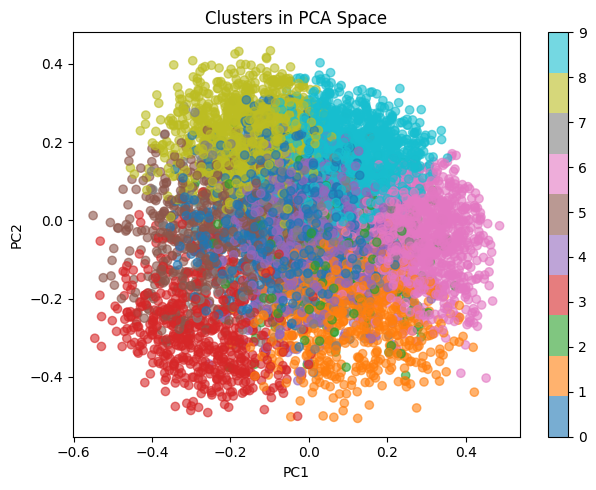

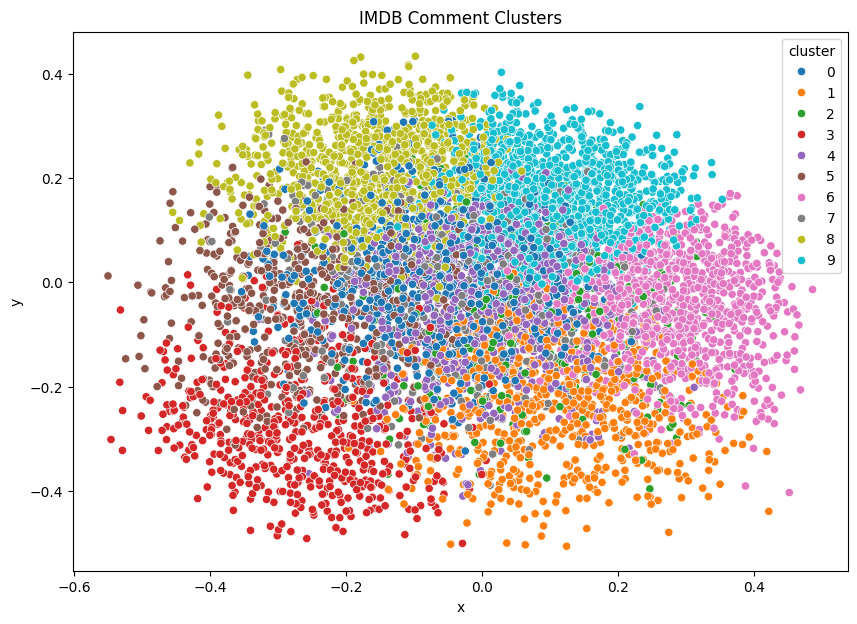

In [127]:
# Run comprehensive analysis
analyze_clusters_comprehensive(df_en, text_column='clean_comment')

# Extract unique n-grams
extract_unique_ngrams(df_en, text_column='processed_comment')

# Analyze themes
analyze_cluster_themes(df_en, text_column='processed_comment')

#get random reviews
get_sample_reviews(df_en, n_samples=3)

# If you have embeddings available
visualize_clusters(df_en, embeddings)
visualize_clusters2(df_en, embeddings)

In [128]:
def print_cluster_table(df):
    # Build the pivot table
    table = df[['title', 'cluster']].value_counts().unstack(fill_value=0)
  
    # Convert floats to ints if needed
    table = table.astype(int)

    # Print each row cleanly
    print("Title".ljust(40), end="")
    for col in table.columns:
        print(f"Cluster {col}".rjust(12), end="")
    print()

    print("-" * (40 + 12 * len(table.columns)))
    
    for title, row in table.iterrows():
        print(title.ljust(40), end="")
        for count in row:
            print(str(count).rjust(12), end="")
        print()

In [129]:
print_cluster_table(df_en)

Title                                      Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4   Cluster 5   Cluster 6   Cluster 7   Cluster 8   Cluster 9
----------------------------------------------------------------------------------------------------------------------------------------------------------------
12 Angry Men                                       4           2           0           0           4           3           5           0           3           4
2001: A Space Odyssey                              3          36           0          14          12          38          18           2          32          45
A Beautiful Mind                                  33           5           1           2          11           2          20           0           2          19
Avatar                                             3          27           4          12           9          13          10          10          47          64
Black Swan                        

In [130]:
table = df_en[['title', 'cluster']].value_counts().unstack()
table.loc